In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

pd.options.display.max_rows = 100000

## Data Wrangling and EDA

In [2]:
restaurants = pd.read_csv(
    "restauranthealthinspections2024_CensusSVIUSDA_halfmileradius.csv"
)
restaurants.head(10)

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractSeniors,USDA_TractWhite,USDA_TractBlack,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,199.0,1387.0,138.0,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,481.0,2603.0,287.0,776.0,36.0,16.0,745.0,1218.0,79.0,50.0
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,320.0,835.0,825.0,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,310.0,1760.0,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-01-02,AFTERS ICE CREAM,6201 HOLLYWOOD BLVD,LOS ANGELES,90028,ROUTINE INSPECTION,97.0,A,NaN,2024,...,310.0,1760.0,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0
6,2024-01-02,ALIBI COFFEE CO,2268 VENICE BLVD,LOS ANGELES,90006,ROUTINE INSPECTION,90.0,A,NaN,2024,...,306.0,1432.0,850.0,358.0,3.0,38.0,1722.0,2949.0,250.0,270.0
7,2024-01-02,ALVARADO MARKET,140 S 5TH ST,MONTEBELLO,90640,ROUTINE INSPECTION,97.0,A,NaN,2024,...,408.0,3448.0,38.0,148.0,9.0,87.0,2933.0,6233.0,183.0,287.0
8,2024-01-02,AMC CENTURY CITY 15 LEVEL 1,10250 SANTA MONICA BLVD # 2000,LOS ANGELES,90067,ROUTINE INSPECTION,98.0,A,NaN,2024,...,1229.0,2081.0,23.0,251.0,2.0,2.0,69.0,88.0,102.0,0.0
9,2024-01-02,ANC OJO DE AGUA PLUS,12726 HADLEY ST,WHITTIER,90601,ROUTINE INSPECTION,95.0,A,STE 105,2024,...,643.0,1988.0,81.0,253.0,2.0,48.0,1220.0,2480.0,266.0,144.0


In [3]:
# encoding datetime information before training model
restaurants["INSPECTION_DATE"] = restaurants["INSPECTION_DATE"].astype("datetime64[ns]")
restaurants["INSPDATE_MONTH"] = restaurants["INSPECTION_DATE"].dt.month
restaurants["INSPDATE_DAY"] = restaurants["INSPECTION_DATE"].dt.day
restaurants.head(10)

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractBlack,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP,INSPDATE_MONTH,INSPDATE_DAY
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,138.0,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0,1,2
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,287.0,776.0,36.0,16.0,745.0,1218.0,79.0,50.0,1,2
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,825.0,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0,1,2
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0,1,2
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2
5,2024-01-02,AFTERS ICE CREAM,6201 HOLLYWOOD BLVD,LOS ANGELES,90028,ROUTINE INSPECTION,97.0,A,NaN,2024,...,305.0,225.0,9.0,24.0,905.0,1426.0,438.0,138.0,1,2
6,2024-01-02,ALIBI COFFEE CO,2268 VENICE BLVD,LOS ANGELES,90006,ROUTINE INSPECTION,90.0,A,NaN,2024,...,850.0,358.0,3.0,38.0,1722.0,2949.0,250.0,270.0,1,2
7,2024-01-02,ALVARADO MARKET,140 S 5TH ST,MONTEBELLO,90640,ROUTINE INSPECTION,97.0,A,NaN,2024,...,38.0,148.0,9.0,87.0,2933.0,6233.0,183.0,287.0,1,2
8,2024-01-02,AMC CENTURY CITY 15 LEVEL 1,10250 SANTA MONICA BLVD # 2000,LOS ANGELES,90067,ROUTINE INSPECTION,98.0,A,NaN,2024,...,23.0,251.0,2.0,2.0,69.0,88.0,102.0,0.0,1,2
9,2024-01-02,ANC OJO DE AGUA PLUS,12726 HADLEY ST,WHITTIER,90601,ROUTINE INSPECTION,95.0,A,STE 105,2024,...,81.0,253.0,2.0,48.0,1220.0,2480.0,266.0,144.0,1,2


In [4]:
# just looking at how many observations is needed minimum to remove columns with 85% NAN
print(
    f"Number of columns in restaurant dataset: {len(restaurants.columns)}, N = {len(restaurants)}, 85% threshold = {int((len(restaurants)*.15))} rows"
)

Number of columns in restaurant dataset: 292, N = 48516, 85% threshold = 7277 rows


In [5]:
# looking at food inspection scores for schools, we'll probably want to take those out
# there are 188 KY, 191 TX, and only 4 places in CA where schools were listed,
# but we should probably take them out anyway, if we're evaluating external validity
restaurants[restaurants["STORE_NAME"].str.contains("SCHOOL", case=False, na=False)][
    "State"
].value_counts()

State
TX    384
KY    307
CA      5
Name: count, dtype: int64

In [6]:
# removings schools from our dataset
restaurants = restaurants[
    ~restaurants["STORE_NAME"].str.contains("SCHOOL", case=False, na=False)
]
len(restaurants)

47820

> One way we can address our class imbalance is by creating a binary classification problem that siphons off some of our 90s scores into the negative class. We'll try this by evaluating our model using a new standard: a stellar pass. While any score above a 90 is probably fine, some of our pickier restaurant-goers report feeling much better about a high 90 score. Thus, we'll establish a threshold for what we will call a "stellar pass" - that is, a pass that will satisfy our pickier customers - and raise the threshold of a "failed" inspection score to a 95.

In [7]:
# creating a dummy variable to represent our strictest measure of success
restaurants["STELLAR_PASS"] = (restaurants["SCORE"] > 95).astype(int)
restaurants.head(10)

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP,INSPDATE_MONTH,INSPDATE_DAY,STELLAR_PASS
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,552.0,0.0,49.0,1720.0,2875.0,308.0,151.0,1,2,0
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,776.0,36.0,16.0,745.0,1218.0,79.0,50.0,1,2,1
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,500.0,5.0,44.0,1244.0,1885.0,154.0,126.0,1,2,1
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,225.0,9.0,24.0,905.0,1426.0,438.0,138.0,1,2,0
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0
5,2024-01-02,AFTERS ICE CREAM,6201 HOLLYWOOD BLVD,LOS ANGELES,90028,ROUTINE INSPECTION,97.0,A,NaN,2024,...,225.0,9.0,24.0,905.0,1426.0,438.0,138.0,1,2,1
6,2024-01-02,ALIBI COFFEE CO,2268 VENICE BLVD,LOS ANGELES,90006,ROUTINE INSPECTION,90.0,A,NaN,2024,...,358.0,3.0,38.0,1722.0,2949.0,250.0,270.0,1,2,0
7,2024-01-02,ALVARADO MARKET,140 S 5TH ST,MONTEBELLO,90640,ROUTINE INSPECTION,97.0,A,NaN,2024,...,148.0,9.0,87.0,2933.0,6233.0,183.0,287.0,1,2,1
8,2024-01-02,AMC CENTURY CITY 15 LEVEL 1,10250 SANTA MONICA BLVD # 2000,LOS ANGELES,90067,ROUTINE INSPECTION,98.0,A,NaN,2024,...,251.0,2.0,2.0,69.0,88.0,102.0,0.0,1,2,1
9,2024-01-02,ANC OJO DE AGUA PLUS,12726 HADLEY ST,WHITTIER,90601,ROUTINE INSPECTION,95.0,A,STE 105,2024,...,253.0,2.0,48.0,1220.0,2480.0,266.0,144.0,1,2,0


In [8]:
restaurants["STELLAR_PASS"].value_counts()

STELLAR_PASS
1    25059
0    22761
Name: count, dtype: int64

> While, yes, this "stellar pass" is a little more arbitrary, we at least have a dataset resembling class balance.

#

In [9]:
# subsetting for each state's restaurants
CA_restaurants = restaurants[restaurants["State"] == "CA"]

In [10]:
# the "stellar" standard yields a far more class-balanced dataset
CA_restaurants["STELLAR_PASS"].value_counts()

STELLAR_PASS
0    17219
1    17070
Name: count, dtype: int64

### Dealing with the NAN values

In [11]:
CA_restaurants.isna().sum()
# dropping rows with NAN values
# restaurants = restaurants.dropna()
# restaurants

INSPECTION_DATE                  0
STORE_NAME                       0
STREET_ADDRESS                   0
CITY                             0
ZIP5                             0
SERVICE_DESCRIPTION              0
SCORE                            0
GRADE                           18
STREET_ADDRESS_LINE2         31182
INSPDATE_YEAR                    0
Latitude                         0
Longitude                        0
Accuracy Score                   0
Accuracy Type                    0
Number                         258
Street                         109
Unit Type                    30654
Unit Number                  30162
City                             0
State                            0
County                           0
Zip                              0
Country                          0
Source                           0
geometry                         0
buffer                           0
STATEFP                         21
COUNTYFP                        21
TRACTCE             

> Because there are quite a few features with a substantial amount of NAN (some very close to the length of the dataset), I will drop columns with 85% NAN values.

In [12]:
print(
    f"Number of columns in CA dataset before dropping 85% NAN: {len(CA_restaurants.columns)}, threshold = {int((len(CA_restaurants)*.15))} rows"
)

Number of columns in CA dataset before dropping 85% NAN: 293, threshold = 5143 rows


> Because there are a number of features with NAN values for a substantial number of observations, we'll drop columns with too many NAN. 

In [13]:
# dropping columns with 85% NAN
CA_restaurants = CA_restaurants.dropna(thresh=(int(len(CA_restaurants) * 0.15)), axis=1)
print(f"Number of columns after dropping 85% NAN: {len(CA_restaurants.columns)}")

Number of columns after dropping 85% NAN: 208


In [14]:
# now that we have a reasonable number of NAN values, we'll prune these out
# CA_restaurants.isna().sum()
# dropping rows with NAN values
print("CA dataset before NAN dropping:", len(CA_restaurants))
CA_restaurants = CA_restaurants.dropna()
print("CA dataset after NAN dropping:", len(CA_restaurants))

CA dataset before NAN dropping: 34289
CA dataset after NAN dropping: 19168


In [15]:
CA_restaurants.head(10)

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,INSPDATE_YEAR,Latitude,...,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP,INSPDATE_MONTH,INSPDATE_DAY,STELLAR_PASS
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,2024,33.859024,...,776.0,36.0,16.0,745.0,1218.0,79.0,50.0,1,2,1
7,2024-01-02,ALVARADO MARKET,140 S 5TH ST,MONTEBELLO,90640,ROUTINE INSPECTION,97.0,A,2024,34.007823,...,148.0,9.0,87.0,2933.0,6233.0,183.0,287.0,1,2,1
8,2024-01-02,AMC CENTURY CITY 15 LEVEL 1,10250 SANTA MONICA BLVD # 2000,LOS ANGELES,90067,ROUTINE INSPECTION,98.0,A,2024,34.059490,...,251.0,2.0,2.0,69.0,88.0,102.0,0.0,1,2,1
9,2024-01-02,ANC OJO DE AGUA PLUS,12726 HADLEY ST,WHITTIER,90601,ROUTINE INSPECTION,95.0,A,2024,33.982560,...,253.0,2.0,48.0,1220.0,2480.0,266.0,144.0,1,2,0
10,2024-01-02,ANDY'S DOUNT,10127 S AVALON BLVD,LOS ANGELES,90003,ROUTINE INSPECTION,100.0,A,2024,33.943900,...,13.0,2.0,37.0,1877.0,3307.0,180.0,459.0,1,2,1
11,2024-01-02,ARBY'S ROAST BEEF,5920 W SUNSET BLVD,LOS ANGELES,90028,ROUTINE INSPECTION,95.0,A,2024,34.097880,...,262.0,2.0,21.0,1423.0,2405.0,340.0,135.0,1,2,0
13,2024-01-02,AV KABOB HOUSE,1341 W AVENUE J,LANCASTER,93534,OWNER INITIATED INSPECTION,92.0,A,2024,34.689958,...,174.0,9.0,60.0,962.0,1546.0,96.0,200.0,1,2,0
14,2024-01-02,BENIHANA,400 S BALDWIN AVE # 901L,ARCADIA,91007,ROUTINE INSPECTION,96.0,A,2024,34.137113,...,1841.0,2.0,15.0,525.0,933.0,32.0,23.0,1,2,1
15,2024-01-02,BIRD BOX,12460 OXNARD ST,NORTH HOLLYWOOD,91606,ROUTINE INSPECTION,94.0,A,2024,34.179256,...,272.0,20.0,32.0,847.0,1494.0,150.0,112.0,1,2,0
18,2024-01-02,BON APPETIT,2900 31ST ST,SANTA MONICA,90405,ROUTINE INSPECTION,97.0,A,2024,34.019038,...,702.0,21.0,33.0,557.0,969.0,145.0,121.0,1,2,1


> Pulling columns with percentage value/share data from the Census tract dataset/food security.

In [16]:
# dropping EP_POV150 since it would likely be collinear with the other variables
CA_restaurants = CA_restaurants.drop(columns=["EP_POV150"])

In [17]:
# pulling 20% of this dataset for our test
CA_restaurant_test = CA_restaurants.sample(frac=0.2, random_state=42)
# drop these 20% pulled from our training set
CA_restaurants = CA_restaurants.drop(CA_restaurant_test.index)

In [18]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_grades = CA_restaurants[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "USDA_PovertyRate",
        "USDA_MedianFamilyIncome",
        "USDA_PCTGQTRS",
        "GRADE",
    ]
]

# appending all columns with "share" in the column name
CA_share_cols = CA_restaurants[CA_restaurants.filter(like="share").columns]
CA_restaurant_model_grades = pd.concat(
    [CA_restaurant_model_grades, CA_share_cols],
    axis=1,
)
# resetting index
CA_restaurant_model_grades.reset_index(drop=True, inplace=True)
CA_restaurant_model_grades.head(10)

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,...,USDA_laseniorshalfshare,USDA_lawhitehalfshare,USDA_lablackhalfshare,USDA_laasianhalfshare,USDA_lanhopihalfshare,USDA_laaianhalfshare,USDA_laomultirhalfshare,USDA_lahisphalfshare,USDA_lahunvhalfshare,USDA_lasnaphalfshare
0,2024,1,2,7.2,54.6,34.3,13.3,11.1,28.6,11.5,...,3.189273,27.795663,0.251159,1.405884,0.071399,0.714946,22.303396,49.148855,6.778290,8.554847
1,2024,1,2,6.2,25.0,0.9,1.1,45.2,11.1,13.2,...,36.100589,63.863004,0.781727,7.466659,0.082372,0.055858,2.121825,2.570727,5.833808,0.000000
2,2024,1,2,12.2,45.5,45.4,16.8,15.3,30.8,14.0,...,1.043259,6.616906,5.671133,0.000000,0.001440,0.117997,6.356435,12.496156,3.557535,6.677187
3,2024,1,2,7.6,43.7,21.3,19.4,9.7,15.8,14.5,...,1.197753,6.651286,1.088966,1.355553,0.009304,0.092756,5.800791,8.532187,4.234097,1.658559
4,2024,1,2,15.8,38.6,12.9,5.3,24.7,20.1,14.8,...,10.500454,24.264871,0.831529,20.616008,0.025272,0.195036,9.605363,17.878311,1.908538,0.898773
5,2024,1,2,6.8,38.0,9.1,6.2,14.5,15.2,13.3,...,0.045275,0.494731,0.046911,0.045222,0.000000,0.008256,0.213618,0.407727,0.021723,0.030244
6,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
7,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
8,2024,1,2,4.8,33.2,17.7,4.1,27.7,18.5,9.7,...,0.182087,0.450568,0.004128,0.620278,0.000000,0.000000,0.229532,0.440741,0.006089,0.098979
9,2024,1,2,3.7,22.7,15.9,8.2,16.4,23.8,10.3,...,6.997303,35.892672,2.853882,5.607811,0.702314,0.335196,18.501895,35.097219,0.867232,3.239686


#

## Multinomial Logistic Regression (using GRADE as our target)

In [19]:
# for the GRADE dataset (multinomial logistic regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)

# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_model_grades.drop("GRADE", axis=1)
y = CA_restaurant_model_grades[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# ABOUT THE LOGISTIC REGRESSION MODEL:
# creating multinomial logistic regression model
# testing other solvers, but apparently, 'lbfgs' is "great for multinomial"
# liblinear only handles binary classification, so we'll test for that later
# doing l2 penalty b/c only liblinear is compatible with l1 and l2

# ABOUT THE OneVsRestClassifier:
# Fits one classifier, LR in this case, per class, used in multiclass logistic regression
# will help us calculate ROC/AUC score and PR for each class relative to the others
# this is why we binarized the labels (e.g. for class A, the negative class is class B and C)
# aka we are translating multinomial log reg = multiple binary classification tasks, one per class
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
    )
)

In [21]:
LR.fit(X_train_grade_scaled, y_train_grade)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 multi_class='multinomial'))

In [22]:
# predicting confidence scores
LR_y_pred = LR.predict_proba(X_test_grade_scaled)

> For multiclass classification, it seems we calculate our ROC/AUC and PR curves differently than the straightforward binary classification models we're used to seeing in class. We essentially turn our question into multiple binary classifications. For example, below, you will see the ROC curve and PR curve for each class. In the multinomial logistic regression below, the blue line (Class 0) models the ROC curve where Class 0 (or an "A" inspection score) is the positive class and Class 1 and 2 ("B" and "C" scores) are the negative class. The orange line represents the ROC curve where Class 1 (or a grade of "B") is the positive class, and Class 0 and 2 ("A" and "C" are the negative class). And so on...

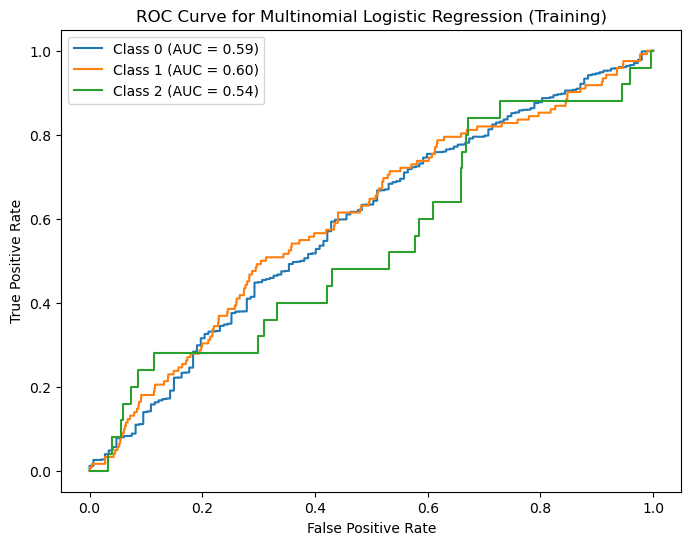

In [23]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression (Training)")
plt.legend()
plt.show()

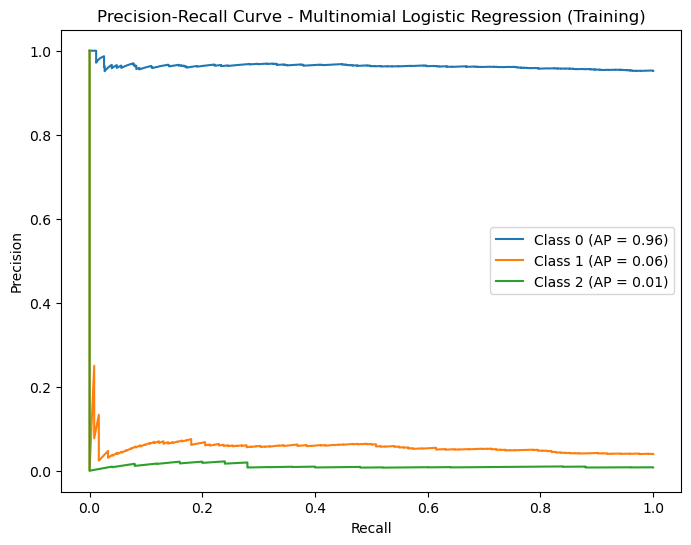

In [24]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression (Training)")
plt.legend()
plt.show()

#

## Random Forest Classifier (using GRADE as our target)

In [25]:
from sklearn.ensemble import RandomForestClassifier

RF_classifier = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
).fit(X_train_grade_scaled, y_train_grade)

In [26]:
RF_cls_y_pred = RF_classifier.predict_proba(X_test_grade_scaled)

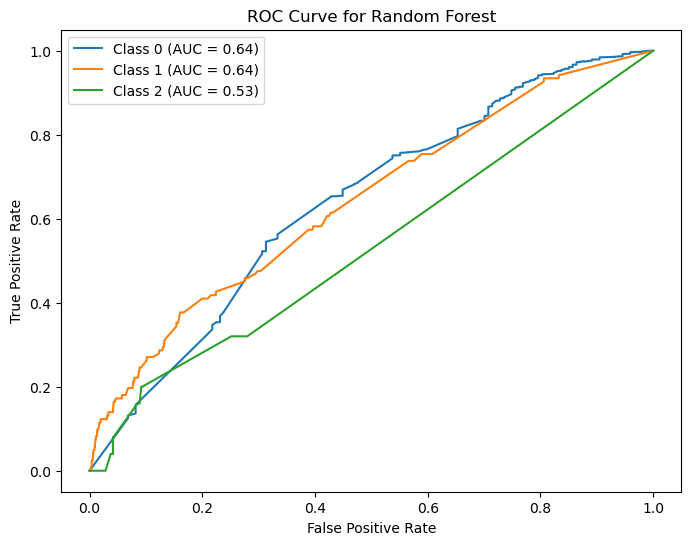

In [27]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], RF_cls_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend()
plt.show()

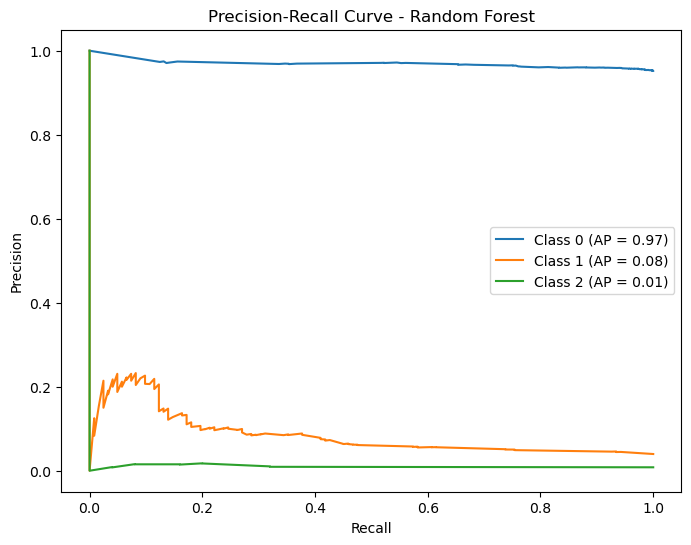

In [28]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], RF_cls_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], RF_cls_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

#

## XGBoost (using GRADE as our target)

In [29]:
from xgboost import XGBClassifier

# multi:softprob > tells XGBoost to perform multi-class classification and outputs class probabilities (not just labels)
# note: we would do softmax for class labels
# eval_metric = mlogloss > common choice for multi-class classification tasks
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    class_weight="balanced",
)

In [30]:
# because we used label_binarize to one hot encode our Y to calculate ROC/AUC and PR,
# we need to pass single-label form, which is what XGBoost expects

# converting one-hot encoded target to class labels
y_train_single = np.argmax(y_train_grade, axis=1)

xgb.fit(X_train_grade_scaled, y_train_single)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [31]:
# predicting probabilities
XGB_y_pred = xgb.predict_proba(X_test_grade)

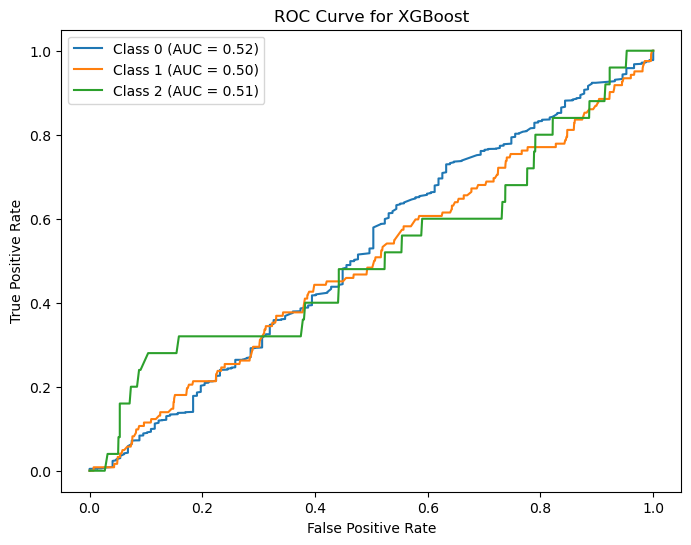

In [32]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], XGB_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.legend()
plt.show()

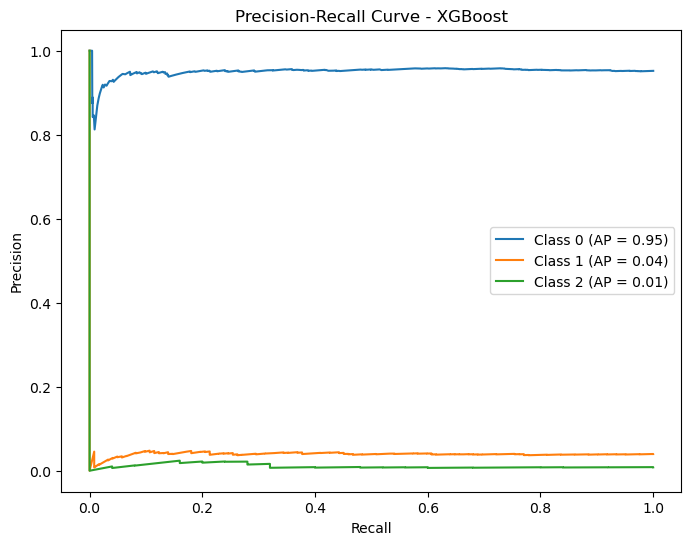

In [33]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], XGB_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], XGB_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.show()

#

## Binomial logistic regression (using our STELLAR_PASS target)

In [34]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_STELLAR_PASS = CA_restaurants[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "USDA_PovertyRate",
        "USDA_MedianFamilyIncome",
        "USDA_PCTGQTRS",
        "STELLAR_PASS",
    ]
]

# appending all columns with "_share" in the column name
CA_share_cols = CA_restaurants[CA_restaurants.filter(like="share").columns]
CA_restaurant_model_STELLAR_PASS = pd.concat(
    [CA_restaurant_model_STELLAR_PASS, CA_share_cols],
    axis=1,
)
# resetting index
CA_restaurant_model_STELLAR_PASS.reset_index(drop=True, inplace=True)
CA_restaurant_model_STELLAR_PASS.head(10)

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,...,USDA_laseniorshalfshare,USDA_lawhitehalfshare,USDA_lablackhalfshare,USDA_laasianhalfshare,USDA_lanhopihalfshare,USDA_laaianhalfshare,USDA_laomultirhalfshare,USDA_lahisphalfshare,USDA_lahunvhalfshare,USDA_lasnaphalfshare
0,2024,1,2,7.2,54.6,34.3,13.3,11.1,28.6,11.5,...,3.189273,27.795663,0.251159,1.405884,0.071399,0.714946,22.303396,49.148855,6.778290,8.554847
1,2024,1,2,6.2,25.0,0.9,1.1,45.2,11.1,13.2,...,36.100589,63.863004,0.781727,7.466659,0.082372,0.055858,2.121825,2.570727,5.833808,0.000000
2,2024,1,2,12.2,45.5,45.4,16.8,15.3,30.8,14.0,...,1.043259,6.616906,5.671133,0.000000,0.001440,0.117997,6.356435,12.496156,3.557535,6.677187
3,2024,1,2,7.6,43.7,21.3,19.4,9.7,15.8,14.5,...,1.197753,6.651286,1.088966,1.355553,0.009304,0.092756,5.800791,8.532187,4.234097,1.658559
4,2024,1,2,15.8,38.6,12.9,5.3,24.7,20.1,14.8,...,10.500454,24.264871,0.831529,20.616008,0.025272,0.195036,9.605363,17.878311,1.908538,0.898773
5,2024,1,2,6.8,38.0,9.1,6.2,14.5,15.2,13.3,...,0.045275,0.494731,0.046911,0.045222,0.000000,0.008256,0.213618,0.407727,0.021723,0.030244
6,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
7,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
8,2024,1,2,4.8,33.2,17.7,4.1,27.7,18.5,9.7,...,0.182087,0.450568,0.004128,0.620278,0.000000,0.000000,0.229532,0.440741,0.006089,0.098979
9,2024,1,2,3.7,22.7,15.9,8.2,16.4,23.8,10.3,...,6.997303,35.892672,2.853882,5.607811,0.702314,0.335196,18.501895,35.097219,0.867232,3.239686


In [35]:
# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_model_STELLAR_PASS.drop("STELLAR_PASS", axis=1)
y = CA_restaurant_model_STELLAR_PASS[["STELLAR_PASS"]]

# train/test split
X_train_STELLAR, X_test_STELLAR, y_train_STELLAR, y_test_STELLAR = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_STELLAR_scaled = scaler.fit_transform(X_train_STELLAR)
X_test_STELLAR_scaled = scaler.fit_transform(X_test_STELLAR)
# scaler = StandardScaler()

In [36]:
LR_stellar = LogisticRegression(max_iter=1000, penalty="l1", solver="liblinear")

In [37]:
# predicting confidence scores
LR_y_pred = LR_stellar.fit(X_train_STELLAR_scaled, y_train_STELLAR).predict_proba(
    X_test_STELLAR_scaled
)[:, 1]

In [38]:
from sklearn.metrics import roc_auc_score

# calculating ROC and AUC
fpr, tpr, _ = roc_curve(y_test_STELLAR, LR_y_pred)
roc_auc = roc_auc_score(y_test_STELLAR, LR_y_pred)

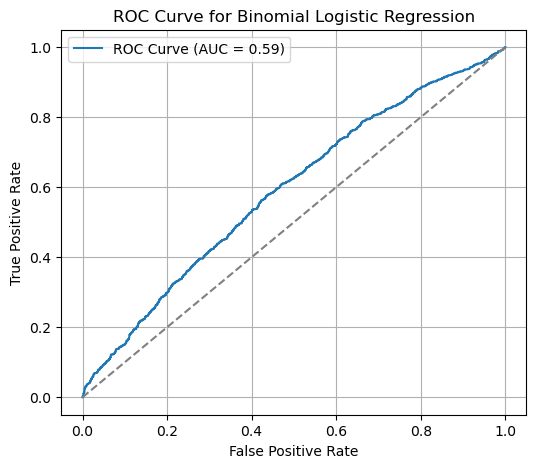

In [39]:
# plotting ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binomial Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

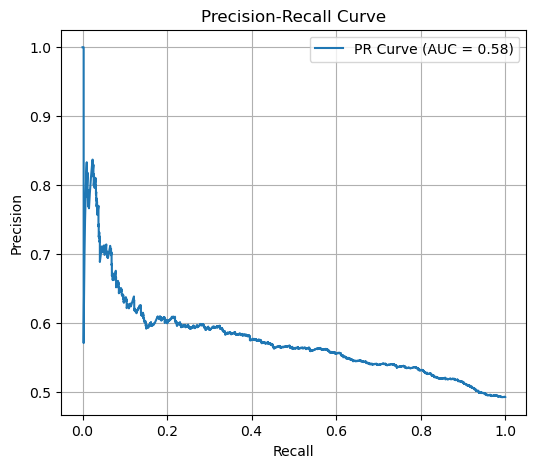

In [40]:
# calculating precision-recall
precision, recall, _ = precision_recall_curve(y_test_STELLAR, LR_y_pred)
pr_auc = average_precision_score(y_test_STELLAR, LR_y_pred)

# plotting PR curves
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

#

## Testing our multinomial logistic regression model on unseen data?

In [41]:
CA_restaurant_test.head(10)

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,INSPDATE_YEAR,Latitude,...,USDA_TractAsian,USDA_TractNHOPI,USDA_TractAIAN,USDA_TractOMultir,USDA_TractHispanic,USDA_TractHUNV,USDA_TractSNAP,INSPDATE_MONTH,INSPDATE_DAY,STELLAR_PASS
30910,2024-11-02,MICHAELS BURGER NO 2,7225 TOPANGA CYN,CANOGA PARK,91303.0,ROUTINE INSPECTION,90.0,A,2024,34.201780,...,791.0,4.0,25.0,1217.0,1786.0,139.0,114.0,11,2,0
15651,2024-05-14,ACAI JOINT,4303 MAINE AVE # 106,BALDWIN PARK,91706,ROUTINE INSPECTION,93.0,A,2024,34.090718,...,784.0,2.0,58.0,2125.0,3976.0,148.0,163.0,5,14,0
627,2024-01-05,PELICANA ARTESIA,11710 SOUTH ST # 104,ARTESIA,90701,ROUTINE INSPECTION,97.0,A,2024,33.857301,...,3009.0,19.0,36.0,1091.0,1859.0,148.0,202.0,1,5,1
20279,2024-07-10,WOOD HANDCRAFTED PIZZA,2861 W SUNSET BLVD,LOS ANGELES,90026,ROUTINE INSPECTION,95.0,A,2024,34.082870,...,485.0,4.0,32.0,930.0,1860.0,138.0,94.0,7,10,0
28990,2024-10-11,ALTA EATS,1860 N ALLEN AVE,PASADENA,91104.0,ROUTINE INSPECTION,90.0,A,2024,34.178028,...,558.0,44.0,31.0,766.0,1163.0,160.0,100.0,10,11,0
6195,2024-02-22,WOON,2920 W TEMPLE ST,LOS ANGELES,90026,ROUTINE INSPECTION,96.0,A,2024,34.074240,...,1842.0,2.0,35.0,1346.0,1979.0,307.0,164.0,2,22,1
33639,2024-12-16,EK VALLEY RESTAURANT OXACA,6121 WASHINGTON BLVD,CULVER CITY,90232.0,ROUTINE INSPECTION,93.0,A,2024,34.031461,...,492.0,24.0,28.0,977.0,1456.0,160.0,63.0,12,16,0
24327,2024-08-24,CATHERINE TERRACE,1 SAINT CATHERINE WAY,AVALON,90704,ROUTINE INSPECTION,93.0,A,2024,33.354757,...,42.0,13.0,22.0,1240.0,1993.0,484.0,162.0,8,24,0
24792,2024-08-29,ASHLAND HILL,2807 MAIN ST,SANTA MONICA,90405,ROUTINE INSPECTION,96.0,A,2024,34.000212,...,369.0,3.0,23.0,461.0,648.0,343.0,129.0,8,29,1
30979,2024-11-04,IHOP RESTAURANT #3527,9012 TAMPA AVE,NORTHRIDGE,91324.0,ROUTINE INSPECTION,98.0,A,2024,34.233970,...,785.0,5.0,23.0,444.0,729.0,78.0,116.0,11,4,1


In [42]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_test_grades = CA_restaurant_test[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "USDA_PovertyRate",
        "USDA_MedianFamilyIncome",
        "USDA_PCTGQTRS",
        "GRADE",
    ]
]

# appending all columns with "_share" in the column name
CA_share_cols = CA_restaurant_test[CA_restaurant_test.filter(like="share").columns]
CA_restaurant_test_grades = pd.concat(
    [CA_restaurant_test_grades, CA_share_cols],
    axis=1,
)
# resetting index
CA_restaurant_test_grades.reset_index(drop=True, inplace=True)
CA_restaurant_test_grades.head(10)

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,...,USDA_laseniorshalfshare,USDA_lawhitehalfshare,USDA_lablackhalfshare,USDA_laasianhalfshare,USDA_lanhopihalfshare,USDA_laaianhalfshare,USDA_laomultirhalfshare,USDA_lahisphalfshare,USDA_lahunvhalfshare,USDA_lasnaphalfshare
0,2024,11,2,8.1,19.3,23.1,6.2,19.3,16.0,8.7,...,0.787006,2.962843,0.144385,0.692228,0.000660,0.058534,0.848036,1.389293,0.470352,0.280704
1,2024,5,14,8.0,43.0,35.4,6.4,18.7,16.3,12.9,...,0.716806,2.432594,0.001167,1.012250,0.000000,0.039464,1.951980,3.948527,0.361759,0.624659
2,2024,1,5,7.3,38.2,22.0,11.1,14.3,21.2,13.2,...,2.860533,8.052330,0.728250,7.501861,0.091557,0.003149,3.927124,7.009987,0.429304,1.756045
3,2024,7,10,4.6,37.5,22.3,23.6,17.7,12.6,8.1,...,0.000000,0.001982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2024,10,11,2.2,27.3,7.6,4.8,20.0,19.9,10.6,...,6.649234,20.320005,2.866369,2.230668,0.045194,0.113181,2.919914,4.818690,2.736683,1.186529
5,2024,2,22,9.6,38.1,22.4,17.7,11.4,18.3,11.3,...,0.002475,0.003576,0.000000,0.010039,0.000000,0.000000,0.008389,0.008389,0.004883,0.002465
6,2024,12,16,5.2,22.5,7.4,6.8,12.2,13.5,9.2,...,0.278224,1.927996,0.198494,0.236011,0.002424,0.112809,1.032406,1.627089,0.317193,0.090033
7,2024,8,24,0.0,34.5,19.7,8.4,16.9,23.2,5.7,...,0.757709,4.102756,0.023552,0.063317,0.008988,0.038115,1.226758,2.250033,1.963114,0.602738
8,2024,8,29,9.0,26.4,1.5,7.4,21.6,7.5,9.0,...,5.602233,16.099546,0.332141,0.914245,0.010378,0.150181,0.838202,0.919202,2.660439,0.734131
9,2024,11,4,1.8,28.1,8.3,14.3,18.6,20.0,12.5,...,17.906553,56.027610,3.949899,16.795981,0.118163,0.497180,9.857590,15.864958,4.214757,6.204639


In [43]:
# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_test_grades.drop("GRADE", axis=1)
y = CA_restaurant_test_grades[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_unseen_grade_scaled = scaler.fit_transform(X)
# scaler = StandardScaler()

In [44]:
# predicting confidence scores
LR_y_unseen_pred = LR.predict_proba(X_unseen_grade_scaled)

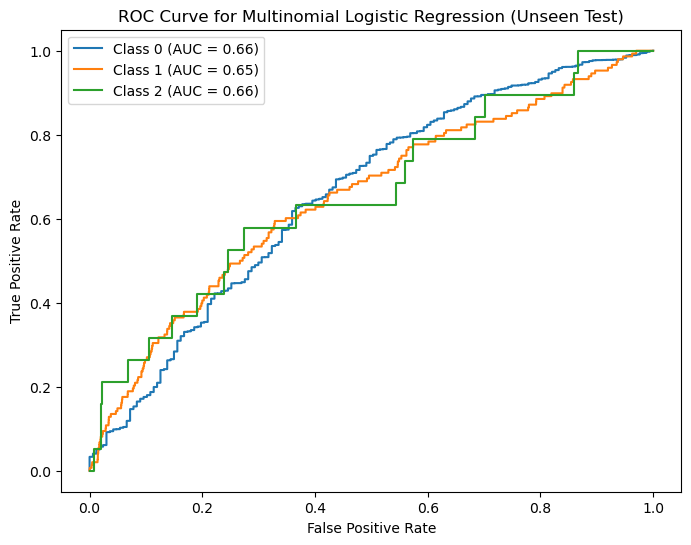

In [45]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], LR_y_unseen_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression (Unseen Test)")
plt.legend()
plt.show()

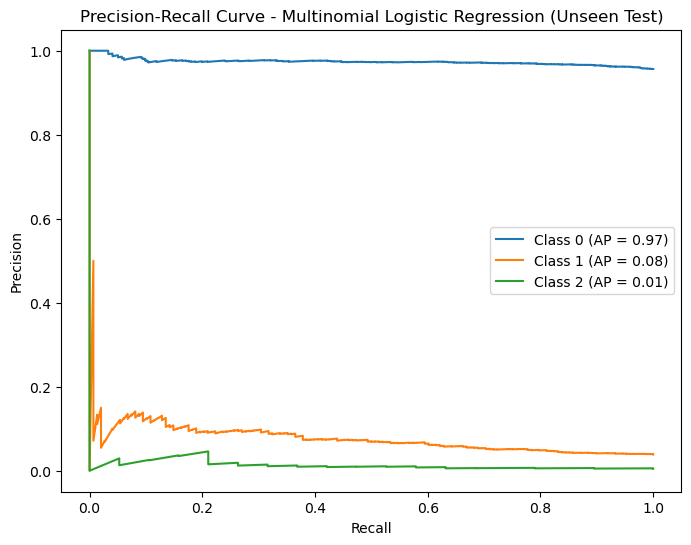

In [46]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_bin[:, i], LR_y_unseen_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_bin[:, i], LR_y_unseen_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression (Unseen Test)")
plt.legend()
plt.show()

##### 